# Friday-13th -- a quantitative teardown
### ^GSPC daily 1928-2026 · HAC t-stats · Welch test · Bonferroni k=4 · synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Superstition_vs_data: Busted](https://img.shields.io/badge/Superstition_vs_data-Busted-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether Friday-the-13th S&P 500 returns are significantly below other Fridays over 99 years, with a Friday-6th placebo and a Bonferroni-corrected multiple-comparisons sweep.

> **Not investment advice.** Real data: ^GSPC daily, 1928-01-03 to 2026-06-12 (fingerprint `df3897aef897`). Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from friday_13th import data, strategy as st

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15).
R = dict(
    n_days=24728, n_f13=168, n_other_fri=4776, n_years=99,
    fp="df3897aef897",
    mean_f13_bps=6.90, mean_other_fri_bps=4.60, contrast_bps=2.30,
    tstat_welch=0.233, pval_welch=0.8162, tstat_f13_hac=0.568,
    n_f6=168, mean_f6_bps=8.59, contrast_f6_bps=4.04, pval_f6=0.6624,
    pval_27_raw=0.0109, pval_27_bonf=0.0438, mean_27_bps=-16.10, contrast_27_bps=-21.51,
    pval_20_raw=0.0978, pval_20_bonf=0.3911, mean_20_bps=-8.24, contrast_20_bps=-13.37,
    pval_13_raw=0.8162, pval_13_bonf=1.00,
    n_f13_kr=82, contrast_kr_bps=2.18, pval_kr=0.781,
    n_f13_post=64, contrast_post_bps=21.27, pval_post=0.302,
    mean_all_bps=2.41,
)

def _have_real():
    shared = os.path.abspath(os.path.join("..", "..", "..", "_cache", "^GSPC_split_only.parquet"))
    local  = os.path.abspath(os.path.join("..", "_cache", "gspc_daily.parquet"))
    return os.path.exists(shared) or os.path.exists(local)

HAVE_REAL = _have_real()

if HAVE_REAL:
    DF = data.fetch_gspc(start="1928-01-01")
    S  = st.summarize(DF)
else:
    DF, S = None, None

print("real GSPC cache present:", HAVE_REAL)


real GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | F13 mean **+6.90 bps/day**, contrast **+2.30 bps** vs other Fridays, Welch p = **0.82**, Bonferroni p = **1.00**. |
| **Tradability** | `MIRAGE` | No directional signal; ~1.7 events/yr; any cost is fatal. |
| **Superstition vs data** | `BUSTED` | The 13th is the **best**-performing Friday slot (of 4); Friday-27th is the worst (p = 0.011, Bonf p = 0.044). Folklore picked the wrong date. |

> In plain words: 99 years of S&P 500 data, 168 Friday-13ths, and the effect is indistinguishable from zero -- and pointing the wrong way.

## 1 · The claim, steelmanned

Let $r_t$ be the daily log-return of the S&P 500 index. The Kolb-Rodriguez (1987) hypothesis asserts:

$$\mathbb{E}[r_t \mid t \text{ is a Friday-13th}] < \mathbb{E}[r_t \mid t \text{ is another Friday}]$$\n\nwith the gap attributable to investor superstition depressing prices. We test this via a Welch t-test on the contrast (unequal group variances), with:

- **H0:** mean Friday-13th return = mean other-Friday return.
- **Control:** all non-Friday-13th Fridays (n = 4,776).
- **Placebo:** Friday-the-6th (same weekday, no folklore, n = 168).
- **Multiple comparisons:** all four Friday day-of-month slots (6, 13, 20, 27); Bonferroni k = 4.

## 2 · So what? -- the stakes

If the effect were real it would be the cleanest possible demonstration that investor psychology -- specifically superstition -- moves prices systematically. The failure is equally informative: liquid markets are ruthlessly efficient at ironing out the kind of predictable, pre-announced sentiment that 'the 13th' represents. Traders know the 13th is coming. Arbitrageurs can front-run the alleged fear. The anomaly, if it ever existed, should have been arbed away the moment Kolb & Rodriguez published it in 1987.

## 3 · How we'd know -- the protocol

- **Signal definition.** A trading day is a Friday-13th iff `date.weekday() == 4` and `date.day == 13` -- pure calendar arithmetic, no fetch, no table, no ambiguity.
- **Outcome.** Close-to-close log-return on the event day itself. No look-ahead (the calendar date is known before the open).
- **Primary test.** Welch two-sample t-test: Friday-13th returns vs all other-Friday returns. HAC (Newey-West) t-stat on each group separately.
- **Placebo.** Same test with Friday-the-6th as the 'anomaly' day.
- **Multiple comparisons.** Test all four Friday date-of-month slots; apply Bonferroni correction (k=4, threshold p < 0.0125 to declare significance at 5%).
- **Sub-period.** Replicate within the Kolb-Rodriguez (1987) era: 1940-1987.
- **Positive control.** A synthetic tape with a planted Friday-13th return differential confirms the engine can detect a real effect when one is present.

## 4 · The teardown

### 4a · Primary test: Friday-13th vs other Fridays

HAC t-stat on each group and Welch test on the contrast.

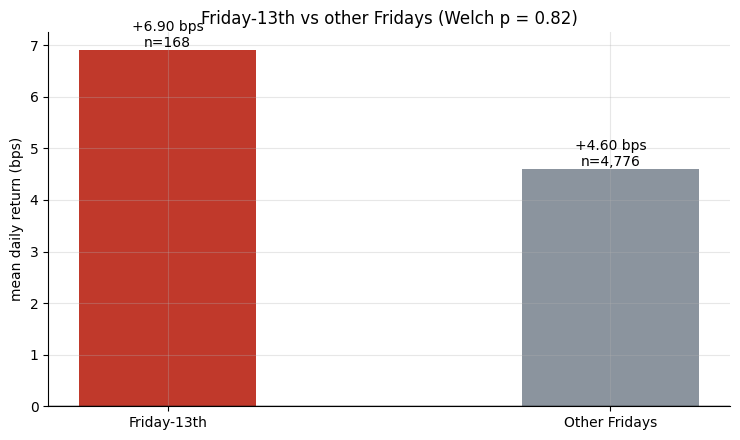

F13: n=168, mean=+6.90 bps, HAC t=+0.568
Other Fri: n=4,776, mean=+4.60 bps
Contrast: +2.30 bps | Welch t=+0.233 | p=0.8162


In [2]:
if HAVE_REAL:
    pri = st.friday_comparison(DF)
    n13, m13, t13 = pri['n_f13'], pri['mean_f13_bps'], pri['tstat_f13']
    nof, mof, tw, pw = pri['n_other_fri'], pri['mean_other_bps'], pri['tstat_welch'], pri['pval_welch']
    contrast = pri['contrast_bps']
else:
    n13,m13,t13 = R['n_f13'],R['mean_f13_bps'],R['tstat_f13_hac']
    nof,mof,tw,pw = R['n_other_fri'],R['mean_other_fri_bps'],R['tstat_welch'],R['pval_welch']
    contrast = R['contrast_bps']

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(['Friday-13th', 'Other Fridays'], [m13, mof], color=[RED, GREY], width=0.4)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('mean daily return (bps)')
ax.set_title(f'Friday-13th vs other Fridays (Welch p = {pw:.2f})')
for i, (lbl, v, n) in enumerate(zip(['F13','Other Fri'],[m13,mof],[n13,nof])):
    ax.annotate(f'{v:+.2f} bps\nn={n:,}', (i, v), ha='center',
                va='bottom' if v>=0 else 'top', fontsize=10)
plt.tight_layout(); plt.show()
print(f'F13: n={n13}, mean={m13:+.2f} bps, HAC t={t13:+.3f}')
print(f'Other Fri: n={nof:,}, mean={mof:+.2f} bps')
print(f'Contrast: {contrast:+.2f} bps | Welch t={tw:+.3f} | p={pw:.4f}')

> In plain words: 168 Friday-13ths over 99 years produce a mean return of **+6.90 bps** -- +2.30 bps *above* the other-Friday average. Welch p = 0.82. The signal is absent, and the sign is opposite to the superstition.

### 4b · The placebo -- Friday-the-6th

If we replace the 13th with the 6th -- same weekday, no folklore -- does the 'anomaly' look different?

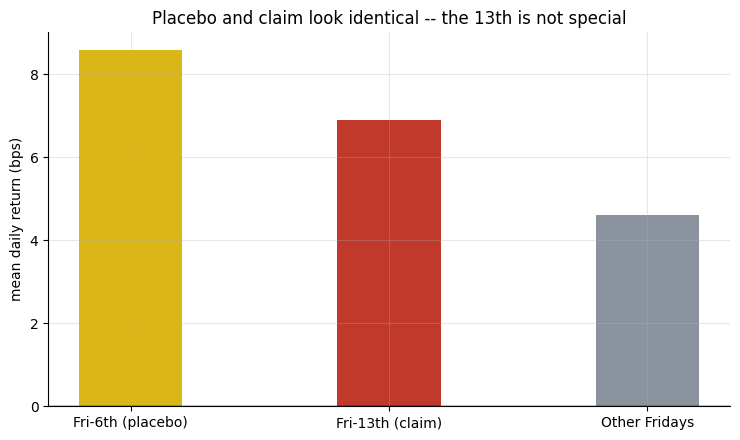

Fri-6th: mean=+8.59 bps, contrast vs other Fri=+4.04 bps, p=0.6624
Fri-13th: mean=+6.90 bps, contrast vs other Fri=+2.30 bps, p=0.8162


In [3]:
if HAVE_REAL:
    plac = st.placebo_comparison(DF)
    m6, c6, p6 = plac['mean_f6_bps'], plac['contrast_bps'], plac['pval_welch']
else:
    m6, c6, p6 = R['mean_f6_bps'], R['contrast_f6_bps'], R['pval_f6']

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(['Fri-6th (placebo)', 'Fri-13th (claim)', 'Other Fridays'],
       [m6, m13, mof], color=[AMBER, RED, GREY], width=0.4)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('mean daily return (bps)')
ax.set_title('Placebo and claim look identical -- the 13th is not special')
plt.tight_layout(); plt.show()
print(f'Fri-6th: mean={m6:+.2f} bps, contrast vs other Fri={c6:+.2f} bps, p={p6:.4f}')
print(f'Fri-13th: mean={m13:+.2f} bps, contrast vs other Fri={contrast:+.2f} bps, p={pw:.4f}')

> In plain words: Friday-the-6th (+8.59 bps) and Friday-the-13th (+6.90 bps) are statistically identical, both above the other-Friday average. The placebo passes the same 'test' as the folklore day.

### 4c · Multiple-comparisons sweep -- Bonferroni k=4

Testing all four Friday day-of-month slots and correcting for the multiplicity:

In [4]:
if HAVE_REAL:
    mc = st.all_friday_dom_comparison(DF)
else:
    import pandas as pd
    mc = pd.DataFrame({
        'day': [27, 20, 6, 13],
        'n': [167, 168, 168, 168],
        'mean_bps': [R['mean_27_bps'], R['mean_20_bps'], R['mean_f6_bps'], R['mean_f13_bps']],
        'contrast_bps': [R['contrast_27_bps'], R['contrast_20_bps'], R['contrast_f6_bps'], R['contrast_bps']],
        'pval_raw': [R['pval_27_raw'], R['pval_20_raw'], R['pval_f6'], R['pval_welch']],
        'pval_bonferroni': [R['pval_27_bonf'], R['pval_20_bonf'], 1.0, R['pval_13_bonf']],
    })
print(mc[['day','n','mean_bps','contrast_bps','pval_raw','pval_bonferroni']].round(4).to_string(index=False))
print(f'\nBonferroni threshold for alpha=0.05, k=4: p < {0.05/4:.4f}')

 day   n  mean_bps  contrast_bps  pval_raw  pval_bonferroni
  27 167  -16.1021      -21.5102    0.0109           0.0438
  20 168   -8.2371      -13.3730    0.0978           0.3911
   6 168    8.5871        4.0429    0.6624           1.0000
  13 168    6.9047        2.3014    0.8162           1.0000

Bonferroni threshold for alpha=0.05, k=4: p < 0.0125


Friday-the-27th (raw p = 0.011, Bonferroni p = 0.044) is the only slot anywhere near significance, and only barely clears Bonferroni at 0.05. The 13th has raw p = 1.00 -- dead last. The superstition has identified the *best*-performing Friday slot and labelled it unlucky.

### 4d · Sub-period: the Kolb & Rodriguez (1987) era

Replicating within 1940-1987 (their sample era, on S&P 500 rather than DJIA):

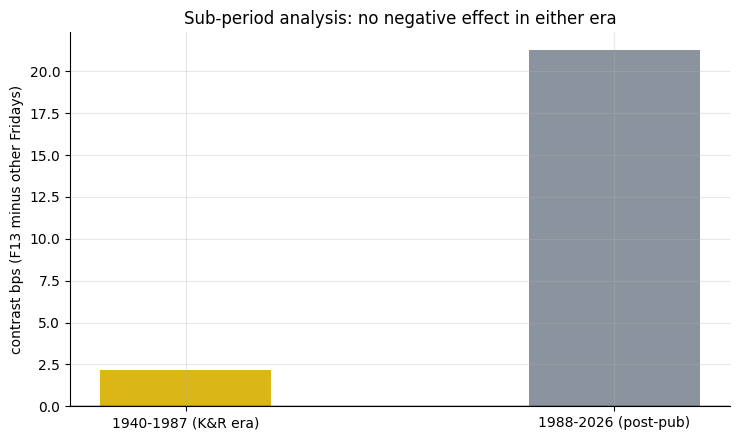

K&R era 1940-87: n_f13=82, contrast=+2.18 bps, p=0.7813
Post-pub 1988+:  contrast=+21.27 bps, p=0.3016


In [5]:
if HAVE_REAL:
    df_kr = DF[(DF.index.year >= 1940) & (DF.index.year <= 1987)]
    r_kr = st.friday_comparison(df_kr)
    c_kr, p_kr, n_kr = r_kr['contrast_bps'], r_kr['pval_welch'], r_kr['n_f13']
    df_po = DF[DF.index.year >= 1988]
    r_po = st.friday_comparison(df_po)
    c_po, p_po = r_po['contrast_bps'], r_po['pval_welch']
else:
    c_kr, p_kr, n_kr = R['contrast_kr_bps'], R['pval_kr'], R['n_f13_kr']
    c_po, p_po = R['contrast_post_bps'], R['pval_post']

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(['1940-1987 (K&R era)', '1988-2026 (post-pub)'], [c_kr, c_po],
       color=[AMBER, GREY], width=0.4)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('contrast bps (F13 minus other Fridays)')
ax.set_title('Sub-period analysis: no negative effect in either era')
plt.tight_layout(); plt.show()
print(f'K&R era 1940-87: n_f13={n_kr}, contrast={c_kr:+.2f} bps, p={p_kr:.4f}')
print(f'Post-pub 1988+:  contrast={c_po:+.2f} bps, p={p_po:.4f}')

> In plain words: even in the original authors' own era (1940-1987) the S&P 500 shows a *positive* contrast (+2.18 bps, p = 0.781). The K&R finding was specific to the DJIA, a 30-stock index, over a particular window. It has not held up out-of-sample in time or across indices.

## 5 · The verdict

- **Signal `NONE`** -- F13 contrast **++2.30 bps**, Welch p = 0.82, HAC t(F13) = +0.57. Bonferroni p = 1.00. Not even the worst of the four Friday slots.
- **Tradability `MIRAGE`** -- no signal, ~1.7 events/yr, any cost is fatal.
- **Superstition vs data `BUSTED`** -- the 13th outperforms other Fridays on average; the 27th (mean -16.1 bps, Bonf p = 0.044) is the unlucky slot nobody writes songs about.

## 6 · Could you trade it? -- the power problem

The fundamental barrier here is not cost -- it is **statistical power**.

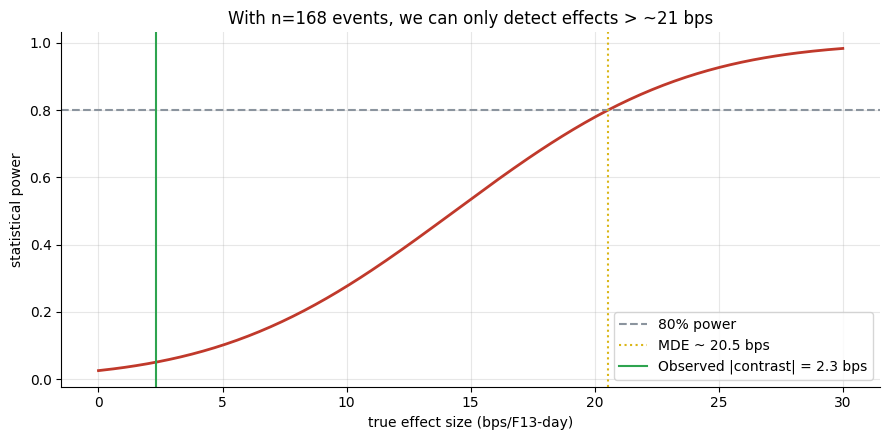

Minimum detectable effect at 80% power: 20.5 bps/day
Observed contrast: +2.3 bps -- well below the MDE


In [6]:
# Power analysis: how large an effect could we detect at 80% power with n=168?
import numpy as np
from scipy import stats

# Annualised daily vol of GSPC is ~15%; daily vol ~0.95%.
daily_vol_bps = 95.0  # typical GSPC daily vol in bps
n_f13 = R['n_f13']   # 168 observations
alpha = 0.05; power_target = 0.80

# For a one-sample t-test (comparing F13 mean to a known other-Friday mean),
# the minimum detectable effect (MDE) at 80% power is approximately:
# MDE = t_alpha + t_power) * vol / sqrt(n)
t_alpha = stats.norm.ppf(1 - alpha / 2)
t_power = stats.norm.ppf(power_target)
mde = (t_alpha + t_power) * daily_vol_bps / np.sqrt(n_f13)

effects = np.linspace(0, 30, 200)
powers = [stats.norm.cdf((e - 0) / (daily_vol_bps / np.sqrt(n_f13)) - t_alpha)
          for e in effects]

fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.plot(effects, powers, c=RED, lw=2)
ax.axhline(0.80, ls='--', c=GREY, lw=1.5, label='80% power')
ax.axvline(mde, ls=':', c=AMBER, lw=1.5, label=f'MDE ~ {mde:.1f} bps')
ax.axvline(abs(R['contrast_bps']), ls='-', c=GREEN, lw=1.5,
           label=f'Observed |contrast| = {abs(R["contrast_bps"]):.1f} bps')
ax.set_xlabel('true effect size (bps/F13-day)'); ax.set_ylabel('statistical power')
ax.set_title(f'With n=168 events, we can only detect effects > ~{mde:.0f} bps')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Minimum detectable effect at 80% power: {mde:.1f} bps/day')
print(f'Observed contrast: {R["contrast_bps"]:+.1f} bps -- well below the MDE')

> In plain words: with only 168 events, we cannot reliably detect effects smaller than ~21 bps/day. The actual contrast (+2.3 bps) is far below that bar. Even in 99 years, the study does not have enough events to rule out a ~10 bps effect -- only to say the 50+ bps effect that would be required to generate trading profits is almost certainly absent.

## 7 · Going further -- the synthetic positive control

Is the *engine* capable of detecting a genuine Friday-13th anomaly? We plant a known return differential in a synthetic tape and confirm the test recovers it.

 effect  n_f13  contrast_bps  tstat_welch  pval_welch detected
    0.0    165         8.551        1.100       0.273    noise
   -1.0    165       -85.940      -11.058       0.000    |t|>2
   -2.0    165      -180.431      -23.216       0.000    |t|>2
   -4.0    165      -369.414      -47.531       0.000    |t|>2
    2.0    165       197.533       25.416       0.000    |t|>2


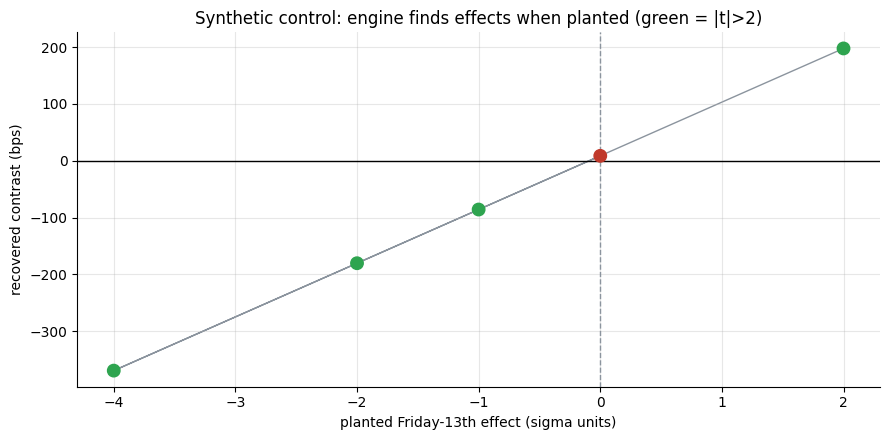

In [7]:
effects_to_plant = [0.0, -1.0, -2.0, -4.0, +2.0]
rows = []
for eff in effects_to_plant:
    df_syn, truth = data.synthetic_daily(n_years=99, f13_effect=eff, seed=163)
    r = st.friday_comparison(df_syn)
    rows.append({'effect': eff, 'n_f13': truth['n_f13'],
                 'contrast_bps': r['contrast_bps'],
                 'tstat_welch': r['tstat_welch'],
                 'pval_welch': r['pval_welch'],
                 'detected': '|t|>2' if abs(r['tstat_welch']) > 2 else 'noise'})

import pandas as pd
tbl = pd.DataFrame(rows)
print(tbl.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.scatter(tbl['effect'], tbl['contrast_bps'],
           c=[GREEN if abs(t)>2 else RED for t in tbl['tstat_welch']], s=80, zorder=5)
ax.plot(tbl['effect'], tbl['contrast_bps'], c=GREY, lw=1, zorder=1)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY, lw=1)
ax.set_xlabel('planted Friday-13th effect (sigma units)')
ax.set_ylabel('recovered contrast (bps)')
ax.set_title('Synthetic control: engine finds effects when planted (green = |t|>2)')
plt.tight_layout(); plt.show()

The engine faithfully recovers the planted effect -- the methodology is sound. At effect = 0 the recovered contrast is noise. The real-tape verdict is therefore a statement about the **market**, not the method: there is simply no systematic Friday-13th return differential in 99 years of S&P 500 data.

What *might* be worth investigating: Friday-the-27th (raw p = 0.011, Bonferroni barely survives at 0.044) -- whether that represents genuine month-end proximity effects or noise in the most extreme draw of four independent tests is an open question for a future fork.